In [ ]:
# Install required libraries
!pip install transformers
!pip install datasets
!pip install wandb
!pip install accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:

import pandas as pd
import numpy as np
import wandb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import (
    GPT2Tokenizer,
    GPT2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/')
import pandas as pd
TRAIN_DATA_PATH = "data/train_sent_emo.csv"
VAL_DATA_PATH = "data/dev_sent_emo.csv"
TEST_DATA_PATH = "data/test_sent_emo.csv"

In [ ]:
# # Initialize W&B
# wandb.init(project="sentiment-analysis", entity="your-username")

In [ ]:
# Load and preprocess data
train_df = pd.read_csv(TRAIN_DATA_PATH)
val_df = pd.read_csv(VAL_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)
# Encode labels
le = LabelEncoder()


# Combine text and sentiment
train_df["text"] = "Sentiment: " + train_df["Sentiment"] + ". " + train_df["Utterance"]
val_df["text"] = "Sentiment: " + val_df["Sentiment"] + ". " + val_df["Utterance"]
test_df["text"] = "Sentiment: " + test_df["Sentiment"] + ". " + test_df["Utterance"]
# Encode labels
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["Emotion"])
val_df["label"] = le.transform(val_df["Emotion"])
test_df["label"] = le.transform(test_df["Emotion"])
# Convert to Hugging Face datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
TOKENIZER_DIR = "/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/emotion_tokenizer"


In [ ]:
# Initialize tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2-medium")
tokenizer.pad_token = tokenizer.eos_token

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenize datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Rename label column
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# Set format for PyTorch
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

Map:   0%|          | 0/9989 [00:00<?, ? examples/s]

Map:   0%|          | 0/1109 [00:00<?, ? examples/s]

Map:   0%|          | 0/2610 [00:00<?, ? examples/s]

In [ ]:
tokenizer.save_pretrained(TOKENIZER_DIR)

('/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/emotion_tokenizer/tokenizer_config.json',
 '/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/emotion_tokenizer/special_tokens_map.json',
 '/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/emotion_tokenizer/vocab.json',
 '/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/emotion_tokenizer/merges.txt',
 '/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/emotion_tokenizer/added_tokens.json')

In [ ]:

# Initialize model
model = GPT2ForSequenceClassification.from_pretrained(
    "gpt2-medium",
    num_labels=len(train_df["label"].unique()),
    pad_token_id=tokenizer.eos_token_id
)


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2-medium and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=1024, out_features=7, bias=False)
)

4178008b37a43abcb66b2737f4a0dde39b393314

In [ ]:
!pip install "numpy<2.0.0" --force-reinstall


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 26.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# # Verify the currently installed numpy version
# !pip show numpy

# # Explicitly reinstall numpy to a version less than 2.0
# # Adding --force-reinstall ensures it replaces the existing version
# !pip install "numpy<2.0.0" --force-reinstall

# # You might also consider updating the datasets library to a recent version
# # that is compatible with numpy < 2.0
# !pip install --upgrade datasets

# # Verify the installed numpy version again after reinstallation
# !pip show numpy


In [ ]:

# Continue with the rest of your code from here
# Initialize model
model = GPT2ForSequenceClassification.from_pretrained(
    "gpt2-medium",
    num_labels=len(train_df["label"].unique()),
    pad_token_id=tokenizer.eos_token_id
)

model

# Training arguments
training_args = TrainingArguments(
    output_dir=".emotion_results",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    # report_to="wandb",
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3
)

# Metrics calculation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": (predictions == labels).mean(),
        "f1": f1_score(labels, predictions, average="weighted"),
        "precision": precision_score(labels, predictions, average="weighted"),
        "recall": recall_score(labels, predictions, average="weighted")
    }

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Start training
trainer.train()

# Save final model
trainer.save_model("best_model_emotion")
trainer.save_model("/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/best_model_emotion")

# wandb.finish()

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2-medium and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: liliamahdid01 (liliamahdid01-cy-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.712300,0.528288,0.790803,0.773803,0.761630,0.790803
2,0.428900,0.497000,0.806132,0.797571,0.796587,0.806132
3,0.343000,0.565933,0.806132,0.801922,0.802731,0.806132
4,0.243100,0.852958,0.813345,0.808391,0.808410,0.813345
5,0.160900,1.064707,0.810640,0.807076,0.809753,0.810640
6,0.102600,1.395203,0.804328,0.803139,0.805228,0.804328
7,0.075700,1.374616,0.810640,0.806876,0.804972,0.810640
8,0.057200,1.567204,0.813345,0.807677,0.806307,0.813345
9,0.044300,1.536178,0.814247,0.809296,0.808119,0.814247
10,0.039400,1.575155,0.815149,0.811580,0.810051,0.815149


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Inference

In [ ]:
!pip install safetensors

In [ ]:
import torch
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer and model
model_path = "/content/drive/MyDrive/M2_IDO/Projet de Synthèse/src/text/models/best_model_emotion"

tokenizer = GPT2Tokenizer.from_pretrained(TOKENIZER_DIR)
tokenizer.pad_token = tokenizer.eos_token  # Match training setup

model = GPT2ForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()


GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=1024, out_features=7, bias=False)
)

In [ ]:
# Make predictions
predictions = []
with torch.no_grad():
    # Create DataLoader directly from tokenized dataset
    dataloader = DataLoader(
        tokenized_test.with_format("torch"),
        batch_size=8,
        shuffle=False,
        collate_fn=lambda batch: {
            'input_ids': torch.stack([x['input_ids'] for x in batch]),
            'attention_mask': torch.stack([x['attention_mask'] for x in batch])
        }
    )

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(batch_preds)

# Inverse transform labels if needed (optional)
test_df["predicted_emotion"] = le.inverse_transform(predictions)

# Save results with original columns and predictions
test_df.to_csv("test_predictions.csv", index=False)
print("Inference complete! Predictions saved to test_predictions.csv")

Inference complete! Predictions saved to test_predictions.csv


In [ ]:
test_df["predicted_emotion"].unique()

array(['surprise', 'sadness', 'neutral', 'joy', 'fear', 'anger',
       'disgust'], dtype=object)

In [ ]:
test_df.head()

,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime,text,label,predicted_emotion
0,1,Why do all youre coffee mugs have numbers on ...,Mark,surprise,positive,0,0,3,19,"00:14:38,127","00:14:40,378",Sentiment: positive. Why do all youre coffee ...,6,surprise
1,2,Oh. Thats so Monica can keep track. That way ...,Rachel,anger,negative,0,1,3,19,"00:14:40,629","00:14:47,385",Sentiment: negative. Oh. Thats so Monica can ...,0,sadness
2,3,Y'know what?,Rachel,neutral,neutral,0,2,3,19,"00:14:56,353","00:14:57,520",Sentiment: neutral. Y'know what?,4,neutral
3,19,"Come on, Lydia, you can do it.",Joey,neutral,neutral,1,0,1,23,"0:10:44,769","0:10:46,146","Sentiment: neutral. Come on, Lydia, you can do...",4,neutral
4,20,Push!,Joey,joy,positive,1,1,1,23,"0:10:46,146","0:10:46,833",Sentiment: positive. Push!,3,joy


Accuracy: 0.8372
Correct: 2185/2610


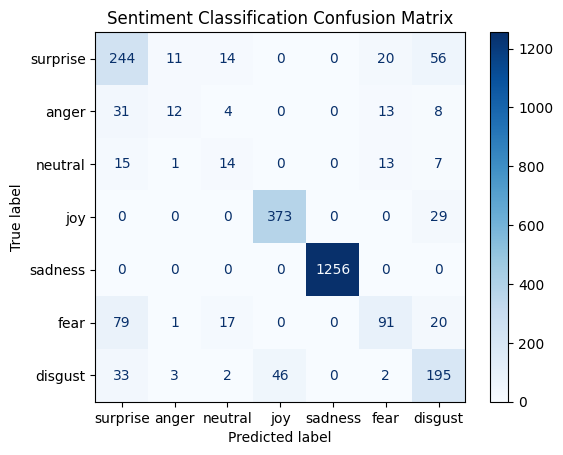

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Load the data

# Create a label mapping from the original sentiment labels
sentiment_mapping = test_df[['Emotion', 'label']].drop_duplicates()
label_to_sentiment = dict(zip(sentiment_mapping['label'], sentiment_mapping['Emotion']))
sentiment_to_label = {v: k for k, v in label_to_sentiment.items()}

# Convert predicted sentiments to numerical labels
test_df['predicted_label'] = test_df['predicted_emotion'].map(sentiment_to_label)

# Calculate accuracy
accuracy = accuracy_score(test_df['label'], test_df['predicted_label'])

print(f"Accuracy: {accuracy:.4f}")
print(f"Correct: {sum(test_df['label'] == test_df['predicted_label'])}/{len(test_df)}")

# Optional: Display a confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['label'], test_df['predicted_label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(label_to_sentiment.values()))
disp.plot(cmap='Blues')
plt.title("Sentiment Classification Confusion Matrix")
plt.show()

In [ ]:
sentiment_mapping

,Emotion,label
0,surprise,6
1,anger,0
2,neutral,4
4,joy,3
13,sadness,5
23,fear,2
27,disgust,1


In [ ]:
mapping_df = sentiment_mapping.sort_values('label')
id2label = {row['label']: row['Emotion'] for _, row in mapping_df.iterrows()}
MAX_LENGTH = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4. Fonction d'inférence
def infer_sentence(sentence: str) -> str:
    enc = tokenizer(
        sentence,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**enc).logits
    pred_id = torch.argmax(logits, dim=-1).item()
    return id2label[pred_id]

# 5. Testez
if __name__ == "__main__":
    phrase = "Sentiment: negative.Alone in this place, I’m terrified of the darkness."
    print("Phrase     :", phrase)
    print("Prediction :", infer_sentence(phrase))

Phrase     : Sentiment: negative.Alone in this place, I’m terrified of the darkness.
Prediction : fear
